# Imports e Configurações

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

sns.set_theme(style="whitegrid")
print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


# Carregamento dos Dados

In [14]:
nome_arquivo = 'dataset_binario_saudavel_vs_patologico.csv'

try:
    df = pd.read_csv(nome_arquivo)
    print(f"Dataset carregado! Total de amostras: {len(df)}")
    print("\nDistribuição das Classes:")
    print(df['Classe_Texto'].value_counts())
except FileNotFoundError:
    print(f"Erro: Arquivo '{nome_arquivo}' não encontrado na pasta atual.")

Dataset carregado! Total de amostras: 1464

Distribuição das Classes:
Classe_Texto
Patológico    777
Saudável      687
Name: count, dtype: int64


# Limpeza e Separação de Features

In [19]:
df = df.dropna()

colunas_para_remover = [
    'Nome_Arquivo', 'Patologia_Original', 'Grupo_Alvo', 
    'ID_Gravacao', 'ID_Paciente', 'Idade', 'Sexo', 
    'Grupo_Binario', 'Classe_Texto'
]

X = df.drop(columns=[col for col in colunas_para_remover if col in df.columns])

y = df['Grupo_Binario']

print(f"Total de features acústicas prontas para uso: {X.shape[1]}")

Total de features acústicas prontas para uso: 9


# Divisão e Padronização

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Tamanho do Treino: {len(y_train)} amostras")
print(f"Tamanho do Teste: {len(y_test)} amostras")
print("Dados separados e padronizados com sucesso!")

Tamanho do Treino: 1024 amostras
Tamanho do Teste: 439 amostras
Dados separados e padronizados com sucesso!


# Treinamento do Modelo SVM

In [21]:
svm_binario = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)

svm_binario.fit(X_train_scaled, y_train)

print("Treinamento concluído com sucesso!")

Treinamento concluído com sucesso!


# Avaliação e Matriz de Confusão

--- RELATÓRIO DE CLASSIFICAÇÃO (BINÁRIO) ---
                precision    recall  f1-score   support

  Saudável (0)       0.70      0.81      0.75       206
Patológico (1)       0.81      0.70      0.75       233

      accuracy                           0.75       439
     macro avg       0.75      0.75      0.75       439
  weighted avg       0.76      0.75      0.75       439



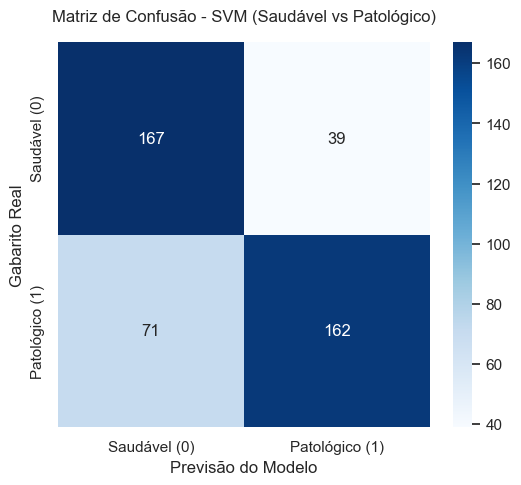

In [22]:
y_pred = svm_binario.predict(X_test_scaled)

print("--- RELATÓRIO DE CLASSIFICAÇÃO (BINÁRIO) ---")
target_names = ['Saudável (0)', 'Patológico (1)']
print(classification_report(y_test, y_pred, target_names=target_names))

matriz = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, 
            yticklabels=target_names)
plt.title("Matriz de Confusão - SVM (Saudável vs Patológico)", pad=15)
plt.ylabel("Gabarito Real")
plt.xlabel("Previsão do Modelo")
plt.show()